<a href="https://colab.research.google.com/github/Dineshok/telco-churn-prediction/blob/main/telco_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ── Stage 1: Load & Explore ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load directly from GitHub (no Kaggle login needed)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# ── Basic look ───────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customer

/tmp/ipykernel_151/1370240099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


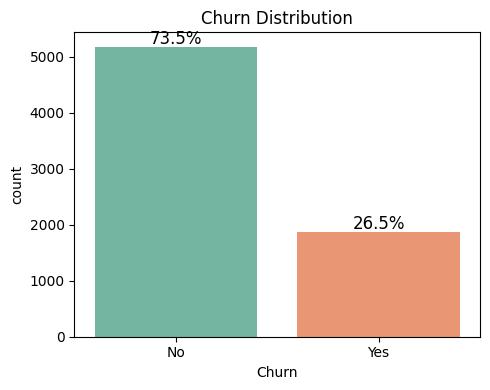

In [5]:
# ── Churn distribution ───────────────────────────────────────────────
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 50),
                ha='center', fontsize=12)

plt.tight_layout()
plt.show()

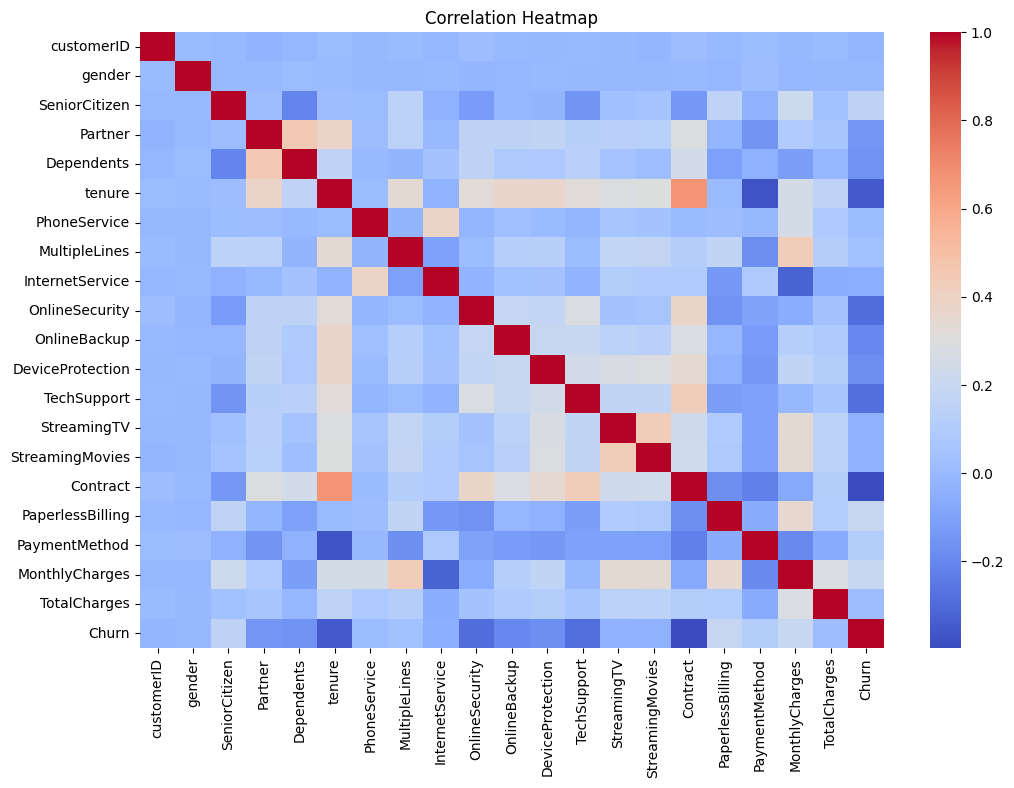

In [6]:
df_encoded = df.copy()

# Convert Yes/No → 1/0
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr = df_encoded.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

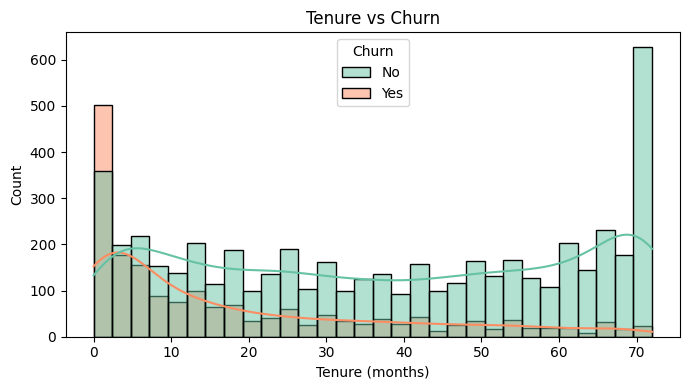

In [7]:
# ── Churn vs Tenure ──────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             kde=True, palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

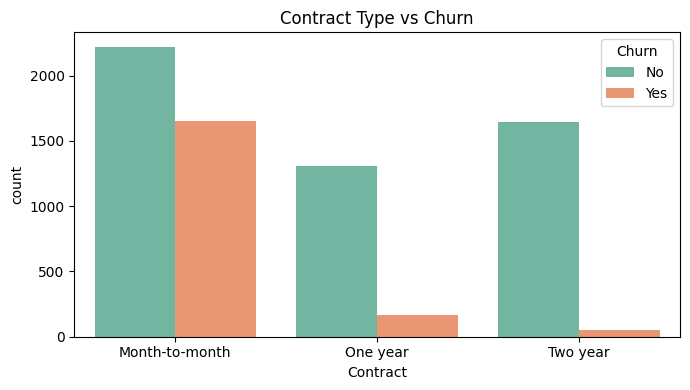

In [8]:
# ── Churn vs Contract Type ───────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()

In [9]:
# ── Stage 2: Preprocessing ───────────────────────────────────────────

# Step 1: Drop customerID (not useful for prediction)
df = df.drop(columns=['customerID'])

# Step 2: Fix TotalCharges — it's a string, convert to float
# Some rows have empty strings " " instead of NaN — this handles that
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs appeared after conversion
print("NaNs in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Those rows have tenure=0 (brand new customers, no charges yet)
# Just fill them with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Encode target column — Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nChurn value counts:\n", df['Churn'].value_counts())

NaNs in TotalCharges after fix: 11

Churn value counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [10]:
# Step 4: Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Churn')  # don't scale the target

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [11]:
# Step 5: One-Hot Encode all categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Sample columns:", df.columns.tolist()[:10])

Shape after encoding: (7043, 31)
Sample columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 6: Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Step 7: Train/Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# stratify=y → keeps churn ratio same in both train and test splits

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nChurn ratio in train:", y_train.mean().round(3))
print("Churn ratio in test: ", y_test.mean().round(3))

X_train shape: (5634, 30)
X_test shape:  (1409, 30)

Churn ratio in train: 0.265
Churn ratio in test:  0.265


In [13]:
# Step 8: Scale numerical columns only
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# fit_transform on train → learns mean and std from training data only
# transform on test → applies same scale (no data leakage)

print("Preprocessing complete ✅")
print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])

Preprocessing complete ✅
Training samples: 5634
Test samples:     1409


In [14]:
# ── Stage 3: Train & Compare Models ──────────────────────────────────

!pip install xgboost -q

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(
                                max_iter=1000,
                                C=1,
                                class_weight='balanced',
                                solver='liblinear',
                                random_state=42
                            ),
    "Decision Tree":       DecisionTreeClassifier(
                                max_depth=5,
                                min_samples_leaf=10,
                                class_weight='balanced',
                                random_state=42
                            ),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                                n_estimators=500,
                                learning_rate=0.05,
                                max_depth=4,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                scale_pos_weight=2.7,
                                eval_metric='logloss',
                                random_state=42
                            )
}

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0, 1, 100)

final_results = []

for name, model in models.items():
    print(f"\n🔹 Processing: {name}")

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision_list = []
    recall_list = []
    f1_list = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        precision_list.append(precision_score(y_test, y_pred))
        recall_list.append(recall_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred))

    # Find best threshold
    best_idx = np.argmax(f1_list)
    best_threshold = thresholds[best_idx]

    best_precision = precision_list[best_idx]
    best_recall = recall_list[best_idx]
    best_f1 = f1_list[best_idx]

    final_results.append({
        "Model": name,
        "Best Threshold": round(best_threshold, 3),
        "Precision": round(best_precision, 3),
        "Recall": round(best_recall, 3),
        "F1-Score": round(best_f1, 3)
    })

# Convert to DataFrame
results_df = pd.DataFrame(final_results).set_index("Model")

print("\n🔥 Best Threshold Results:")
print(results_df)


🔹 Processing: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


🔹 Processing: Decision Tree


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


🔹 Processing: AdaBoost


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


🔹 Processing: XGBoost


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔥 Best Threshold Results:
                     Best Threshold  Precision  Recall  F1-Score
Model                                                           
Logistic Regression           0.566      0.541   0.743     0.626
Decision Tree                 0.606      0.592   0.660     0.625
AdaBoost                      0.475      0.592   0.668     0.628
XGBoost                       0.525      0.544   0.741     0.627



Processing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

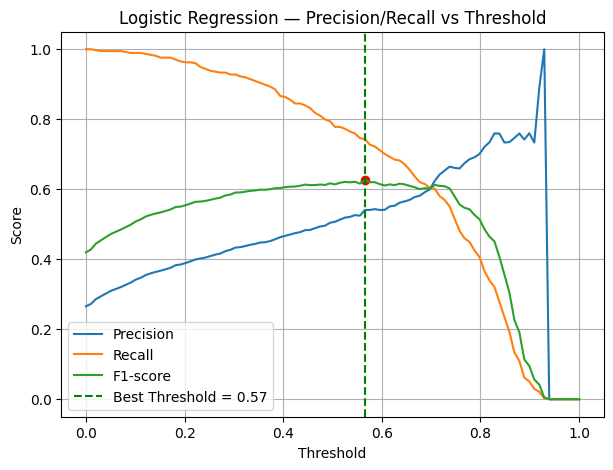

Best Threshold: 0.566
Precision: 0.541
Recall:    0.743
F1-score:  0.626

Processing Decision Tree...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

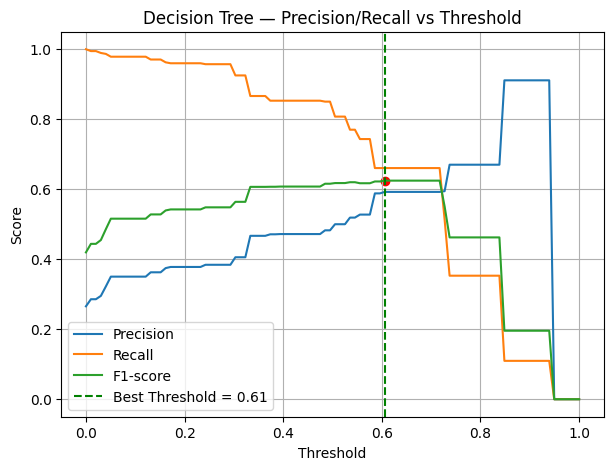

Best Threshold: 0.606
Precision: 0.592
Recall:    0.660
F1-score:  0.625

Processing AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

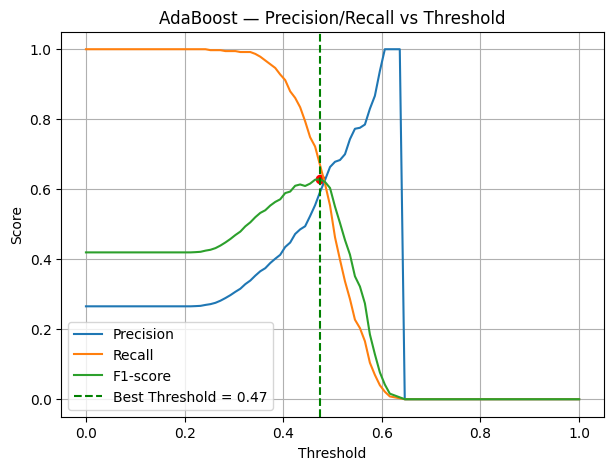

Best Threshold: 0.475
Precision: 0.592
Recall:    0.668
F1-score:  0.628

Processing XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


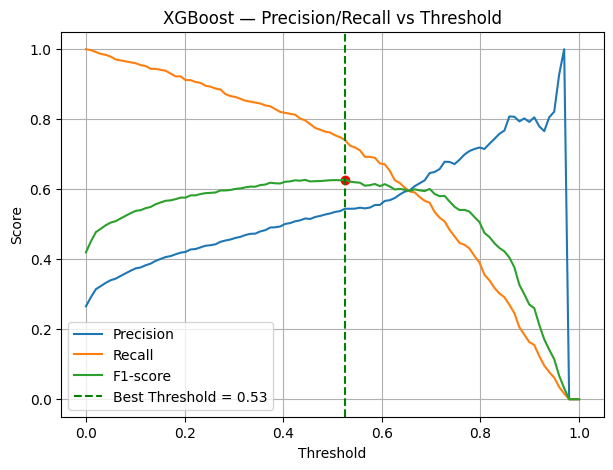

Best Threshold: 0.525
Precision: 0.544
Recall:    0.741
F1-score:  0.627


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0, 1, 100)

for name, model in models.items():
    print(f"\nProcessing {name}...")

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision_list = []
    recall_list = []
    f1_list = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        precision_list.append(precision_score(y_test, y_pred))
        recall_list.append(recall_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred))

    # Best threshold (based on F1)
    best_idx = np.argmax(f1_list)
    best_threshold = thresholds[best_idx]

    best_precision = precision_list[best_idx]
    best_recall = recall_list[best_idx]

    # 📊 Plot for THIS model
    plt.figure(figsize=(7,5))

    plt.plot(thresholds, precision_list, label="Precision")
    plt.plot(thresholds, recall_list, label="Recall")
    plt.plot(thresholds, f1_list, label="F1-score")

    # Vertical line for best threshold
    plt.axvline(best_threshold, linestyle='--', color='green',
                label=f'Best Threshold = {best_threshold:.2f}')

    # Highlight best point
    plt.scatter(best_threshold, f1_list[best_idx], color='red')

    plt.title(f"{name} — Precision/Recall vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🧠 Print values
    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"Precision: {best_precision:.3f}")
    print(f"Recall:    {best_recall:.3f}")
    print(f"F1-score:  {f1_list[best_idx]:.3f}")

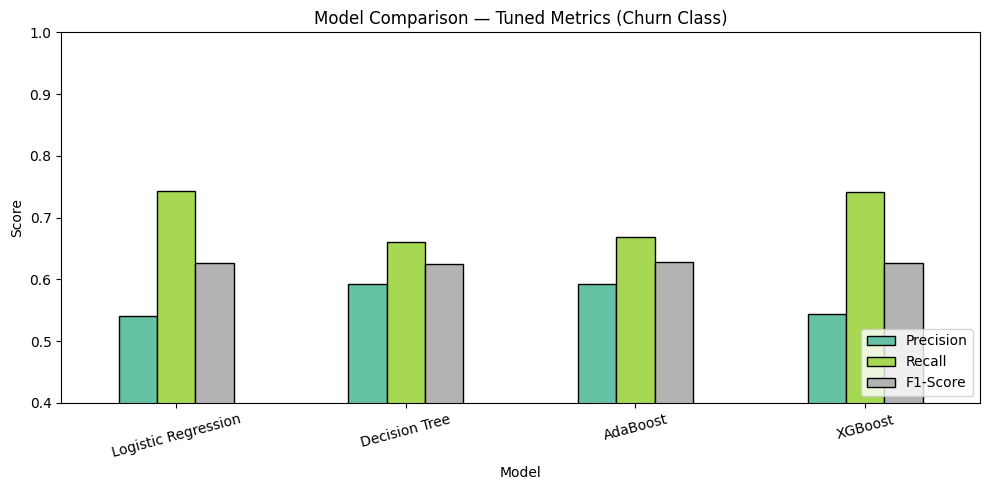

In [19]:
results_df[['Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black'
)

plt.title('Model Comparison — Tuned Metrics (Churn Class)')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.4, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [20]:
# ── Save best model reference for Stage 4 ────────────────────────────
best_model = models["Logistic Regression"]

In [22]:
!pip install numpy==1.26.4 shap --quiet

In [24]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ✅ Train model properly
best_model = models["Logistic Regression"]
best_model.fit(X_train, y_train)

# Convert to numpy
X_train_np = X_train.values
X_test_np  = X_test.values

# ✅ Create explainer
explainer = shap.LinearExplainer(best_model, X_train_np)

# ✅ Get SHAP values (new style)
shap_vals = explainer(X_test_np)

print("SHAP values shape:", shap_vals.values.shape)
print("SHAP ready ✅")

SHAP values shape: (1409, 30)
SHAP ready ✅


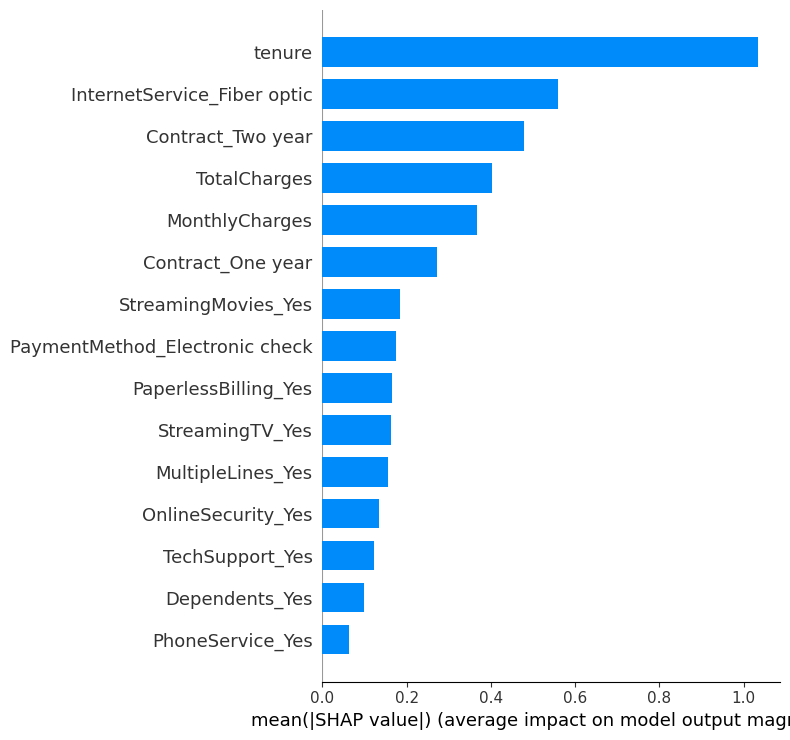

In [25]:
shap.summary_plot(
    shap_vals.values,
    X_test_np,
    feature_names=X_test.columns.tolist(),
    plot_type="bar",
    max_display=15
)

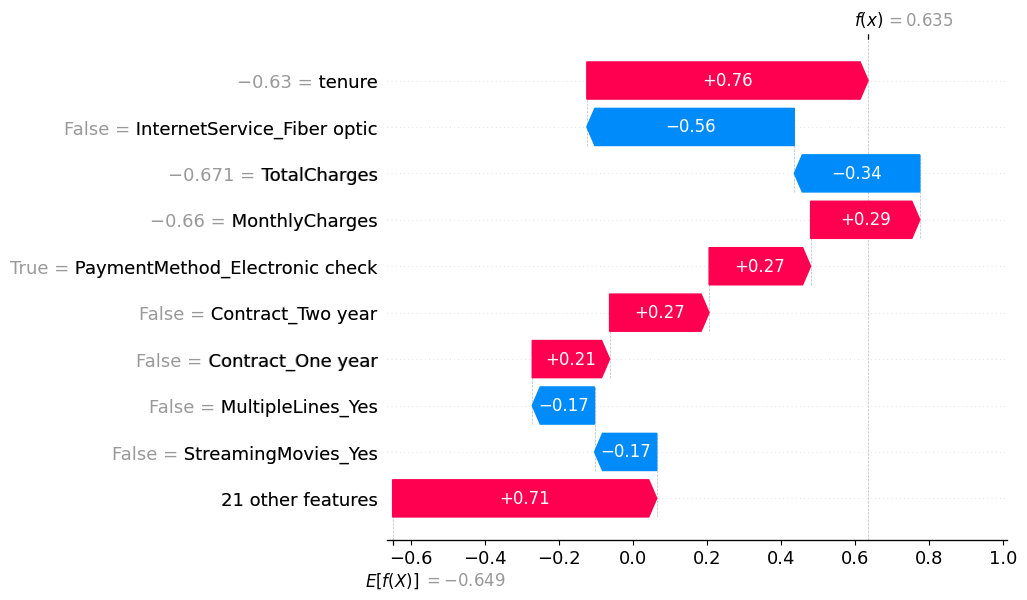

In [26]:
# Get a churned sample
churn_indices = y_test[y_test == 1].index.tolist()
sample_idx = X_test.index.get_loc(churn_indices[0])

# Base value handling
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals.values[sample_idx],
        base_values=base_value,
        data=X_test_np[sample_idx],
        feature_names=X_test.columns.tolist()
    )
)

In [27]:
# ── Save model and scaler ─────────────────────────────────────────────

import pickle
from google.colab import files

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column names (needed to align input in the app)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# ✅ Save best threshold
best_threshold = results_df.loc["Logistic Regression", "Best Threshold"]

with open('threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

# Download all 3 to your computer
files.download('model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

print("All files saved and downloaded ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files saved and downloaded ✅
